# 📊 Project Overview: Curve Fitting & Statistical Modeling

This project centers on **Non-Linear Regression** (Curve Fitting) using the `lmfit` library, with a strong emphasis on **Uncertainty Quantification**—a critical principle in scientific Data Science. The goal is to fit a complex, custom-defined model to experimental data that includes inherent errors ($\sigma_y$).

---

## 🔬 Data Science & Statistical Modeling Principles

### 1. Data Exploration and Model Specification

| Task | Data Science Principle | Function/Goal |
| :--- | :--- | :--- |
| **Ex. 1.1** | **Exploratory Data Analysis (EDA) & Visualization** | **Plotting the data** *with error bars* to understand the functional shape and quality. Errors are crucial for weighted regression. |
| **Ex. 1.1** | **Model Specification / Feature Engineering** | **Defining the model** (polynomials + sines). This is the *Model Hypothesis*, where the analyst must choose a functional form that plausibly captures the observed patterns (trend + periodic behavior). |
| **Ex. 1.2** | **Initial Parameter Estimation** | **Playing with initial guesses** before fitting. Poor initial guesses can lead to local minima; good initial guesses are essential for the convergence of non-linear optimization algorithms. |

### 2. Regression and Uncertainty Quantification

| Task | Statistical Modeling Principle | Function/Goal |
| :--- | :--- | :--- |
| **Ex. 1.2** | **Weighted Non-Linear Least Squares (WNLLS)** | **Fitting the model** by passing the **uncertainties** (inverse of the errors squared) as weights. This ensures data points with smaller uncertainties (higher confidence) have a greater influence on the fit. |
| **Ex. 1.4** | **Model Evaluation & Interpretation** | Retrieving **best-fit parameters**, **parameter uncertainties**, and the **$\chi^2$ value**. The $\chi^2$ value is the primary goodness-of-fit metric in WNLLS, indicating how well the model aligns with the data, accounting for errors. |
| **Ex. 1.4** | **Model Selection** | **Comparing different models** to determine which functional form provides the most acceptable balance of fit quality and complexity. |

### 3. Advanced Uncertainty Visualization

This section focuses on rigorously visualizing and quantifying the **model uncertainty** (the uncertainty in the prediction itself), not just the data errors.

| Task | Statistical Principle | Method & Focus |
| :--- | :--- | :--- |
| **Ex. 1.6 (A)** | **Monte Carlo Simulation / Propagation of Error** | **The Hand-made Way:** Using the fitted parameters' **covariance matrix** to randomly sample parameter sets from a **multivariate normal distribution**. This is the gold standard for visualizing the true model uncertainty, as it accounts for correlations between the parameters. |
| **Ex. 1.6 (B)** | **Simple Standard Deviation (The 'Not the Best' Way)** | A simplified estimation method that often *underestimates* true model uncertainty, especially in complex non-linear models. |
| **Ex. 1.6 (C)** | **Library-Specific Uncertainty (The Quick Way)** | Utilizing built-in `lmfit` methods (like `conf_interval` or `calc_uncertainty`) to quickly and reliably compute confidence bounds around the fitted curve. |
| **Ex. 1.7** | **Optimization Method Comparison** | Comparing `model.fit()` (a high-level abstraction) vs. `lmfit.minimize()` (a lower-level direct optimization of the residual function). Both are core to numerical **optimization**. |

### 4. Automation and Generalization

| Task | Data Science / ML Engineering Principle | Goal |
| :--- | :--- | :--- |
| **Ex. 1.3 [Bonus]** | **Hyperparameter Optimization (Initial Guessing)** | Thinking about **automating the initial guessing** process. This relates directly to the challenge in non-linear models where the initial starting point can determine the final fit, a problem often solved using grid search, random search, or more advanced ML techniques. |
| **Ex. 1.8 [Bonus]** | **Hyperparameter/Model Search** | Trying different combinations of polynomial degree and number of sines. This is a manual form of **Grid Search** or **Model Tuning** to find the optimal complexity for the given data. |

In [58]:
import pandas as pd
from lmfit import Model
import matplotlib.pyplot as plt
import numpy as np
import lmfit



# Exercise 1.1-1.5

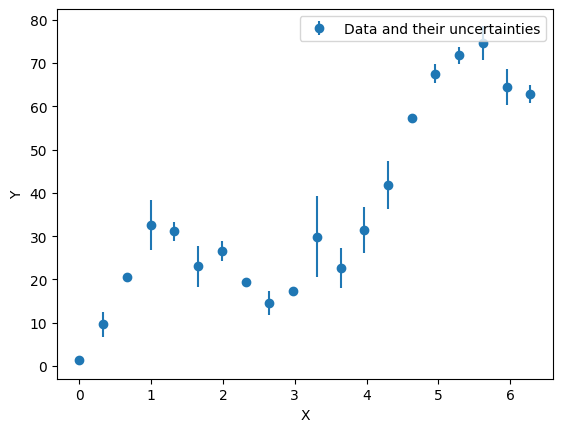

In [59]:
#plotting the data
data = pd.read_csv("HW01_data_with_errors.csv")



X = data['X'].values  
y = data['y'].values  
yerror = data['y_error'].values  


plt.errorbar(X, y, yerr=yerror,  marker="o", ls="none",label='Data and their uncertainties')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

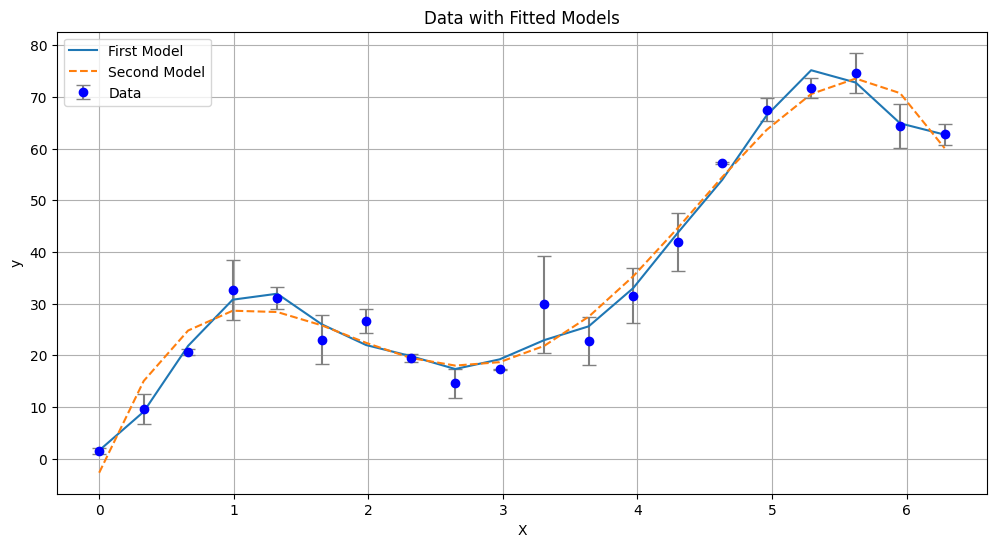

Beta1 hat is -22.687943883948446
Beta2 hat is 2048.186150632465
Beta3 hat is -2046.5995854070384
Beta4 hat is -824.5625529104636
Beta5 hat is -252.64168784535556
Beta6 hat is 225.49673255802696
Beta7 hat is -39.190252057937776
Beta8 hat is 2.076287646319012
Beta9 hat is 6.299661486318277

The uncertainty of Beta1 is 28.20294916343929
The uncertainty of Beta2 is 813.1306897551485
The uncertainty of Beta3 is 812.5903093434852
The uncertainty of Beta4 is 332.9833915560745
The uncertainty of Beta5 is 91.1845999290528
The uncertainty of Beta6 is 85.46865874859014
The uncertainty of Beta7 is 14.949495028063179
The uncertainty of Beta8 is 0.7931321367041596
The uncertainty of Beta9 is 0.3211317342890521

The chi-squared value of the first model is: 137.56974689520422
The chi-squared value of the second model is: 310.4179845875725


The best model is the first one because it has a lower akaike value: 56.56797530183416 in comparison to the second one's: 64.84374906227792

fit report for the fir

In [65]:
#assuming a model based on a function composed by a summation of a polynomial and several sines



#first model function
def model_func(x, beta1, beta2, beta3, beta4, beta5, beta6, beta7, beta8, beta9,):
    return (x * beta1 + beta2+ np.sin(beta9 * x) + beta3 * np.cos(x) + beta4 * x**2 +
            beta5 * x**3 + beta6 * x**4 + beta7 * x**5 + beta8 * x**6)

#second model function
def second_model_func(x, beta1, beta2, beta3, beta4, beta5):
    return beta1 + beta2 * x + beta3 * x**2 + beta4 * np.sin(beta5 * x)


mymodel = Model(model_func)

# setting the parameters:
params = mymodel.make_params(beta1=0.0, beta2=0.0, beta3=0.0, beta4=0.0, beta5=0.0, beta6=0.0, beta7=0.0, beta8=0.0, beta9=1.0)


for param in params:
    params[param].stderr = np.mean(yerror)

result = mymodel.fit(y, params, x=X)

model2 = Model(second_model_func)

params2 = model2.make_params(beta1=0.0, beta2=0.0, beta3=0.0, beta4=0.0, beta5=1.0)

for param in params2:
    params2[param].stderr = np.mean(yerror)


result2 = model2.fit(y, params=params2, x=X)

# Retrieve the best-fit parameters and their uncertainties for the first model

beta1_hat = result.params["beta1"].value
beta2_hat = result.params["beta2"].value
beta3_hat = result.params["beta3"].value
beta4_hat = result.params["beta4"].value
beta5_hat = result.params["beta5"].value
beta6_hat = result.params["beta6"].value
beta7_hat = result.params["beta7"].value
beta8_hat = result.params["beta8"].value
beta9_hat = result.params["beta9"].value

beta1_unc = result.params["beta1"].stderr
beta2_unc = result.params["beta2"].stderr
beta3_unc = result.params["beta3"].stderr
beta4_unc = result.params["beta4"].stderr
beta5_unc = result.params["beta5"].stderr
beta6_unc = result.params["beta6"].stderr
beta7_unc = result.params["beta7"].stderr
beta8_unc = result.params["beta8"].stderr
beta9_unc = result.params["beta9"].stderr

plt.figure(figsize=(12, 6))
plt.errorbar(X, y, yerr=yerror, fmt='o', color='blue', ecolor='gray', capsize=5, label='Data')
plt.plot(X, result.best_fit, '-', label='First Model')
plt.plot(X, result2.best_fit, '--', label='Second Model')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Data with Fitted Models')
plt.legend()
plt.grid(True)
plt.show()

# printing the best-fit parameters for the first model
print(f"Beta1 hat is {beta1_hat}")
print(f"Beta2 hat is {beta2_hat}")
print(f"Beta3 hat is {beta3_hat}")
print(f"Beta4 hat is {beta4_hat}")
print(f"Beta5 hat is {beta5_hat}")
print(f"Beta6 hat is {beta6_hat}")
print(f"Beta7 hat is {beta7_hat}")
print(f"Beta8 hat is {beta8_hat}")
print(f"Beta9 hat is {beta9_hat}")
print()
# printing the uncertainties for the first model parameters
print(f"The uncertainty of Beta1 is {beta1_unc}")
print(f"The uncertainty of Beta2 is {beta2_unc}")
print(f"The uncertainty of Beta3 is {beta3_unc}")
print(f"The uncertainty of Beta4 is {beta4_unc}")
print(f"The uncertainty of Beta5 is {beta5_unc}")
print(f"The uncertainty of Beta6 is {beta6_unc}")
print(f"The uncertainty of Beta7 is {beta7_unc}")
print(f"The uncertainty of Beta8 is {beta8_unc}")
print(f"The uncertainty of Beta9 is {beta9_unc}")
print()
# Compare the akaike values of both models
chi_squared_value = result.chisqr
chi_squared_second = result2.chisqr
print(f"The chi-squared value of the first model is: {chi_squared_value}")
print(f"The chi-squared value of the second model is: {chi_squared_second}")
print()
model1_akaike=result.aic
model2_akaike=result2.aic
print()

# Determine the best model based on akaike values
if model1_akaike < model2_akaike:
    print(f"The best model is the first one because it has a lower akaike value: {model1_akaike} in comparison to the second one's: {model2_akaike}")
else:
    print(f"The best model is the second one because it has a lower akaike value: {model2_akaike} in comparison to the first one's: {model1_akaike}")

# The closer the akaike is to the number of our data points, the more accurate the model is the first one
print()
# fit reports for both models:
print("fit report for the first model:",result.fit_report())
print("fit report for the second model:",result2.fit_report())

# Exercise 1.6

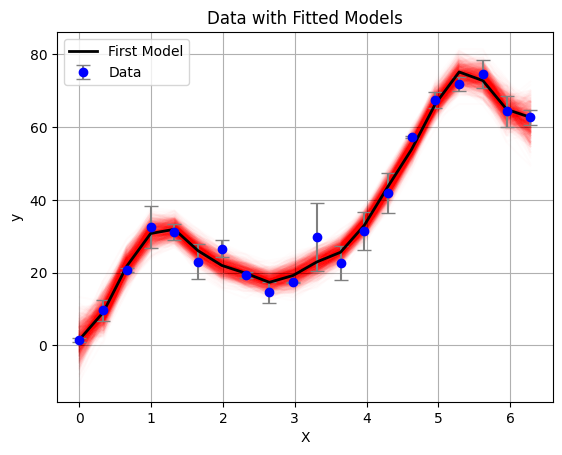

In [66]:
# implementation of the "handmade way using the 1000 curves:"
num_samples = 1000

def model_samples(x, params):
    return (x * params[0] + params[1] + np.sin(params[8] * x) + params[2] * np.cos(x) +
            params[3] * x**2 + params[4] * x**3 + params[5] * x**4 + params[6] * x**5 + params[7] * x**6)

covar_matrix = result.covar
  
best_fit_params = np.array([result.params[key].value for key in result.params])


sampled_params = np.random.multivariate_normal(best_fit_params, covar_matrix, size=num_samples)
for params in sampled_params:
    plt.plot(X, model_samples(X,params), color='red', alpha = 0.01)
plt.errorbar(X, y, yerr=yerror, fmt='o', color='blue', ecolor='gray', capsize=5, label='Data')
plt.plot(X, result.best_fit, '-', label='First Model', color='black', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Data with Fitted Models')
plt.legend()
plt.grid(True)
plt.show()

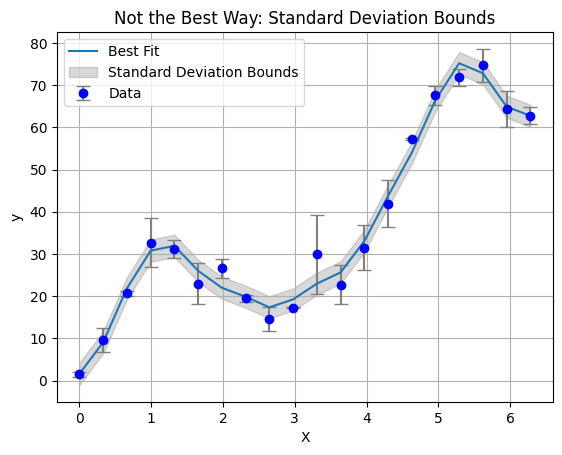

In [67]:
# implementation of the "not best way" approach:
y_fit = result.best_fit
residuals = y - y_fit
std_deviation = np.std(residuals)

# Upper and lower bounds
upper_bound = y_fit + std_deviation
lower_bound = y_fit - std_deviation

# plot
plt.errorbar(X, y, yerr=yerror, fmt='o', color='blue', ecolor='gray', capsize=5, label='Data')
plt.plot(X, y_fit, '-', label='Best Fit')
plt.fill_between(X, lower_bound, upper_bound, color='gray', alpha=0.3, label='Standard Deviation Bounds')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Not the Best Way: Standard Deviation Bounds')
plt.legend()
plt.grid(True)
plt.show()

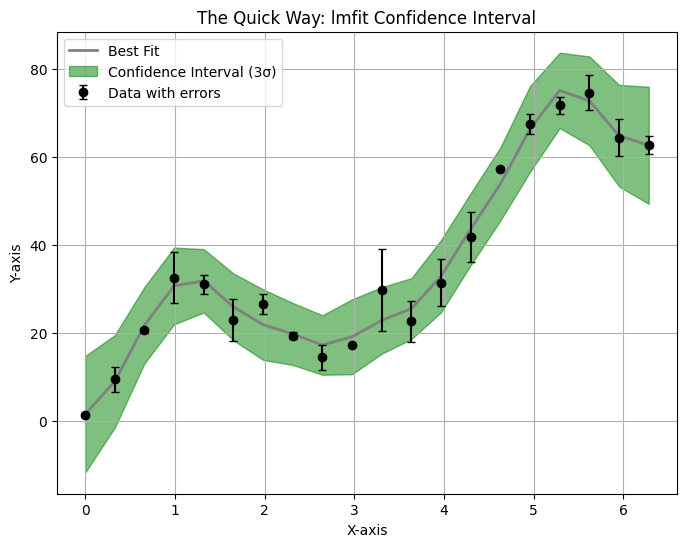

In [68]:
# Implementation of the "quick way" using lmfit methodology:

# assigning and calculating the confidence intervals for the y values
conf_intervals = result.eval_uncertainty(sigma=3, x=X)

#plot
plt.figure(figsize=(8, 6))
plt.plot(X, y_fit, color= 'grey', label='Best Fit', linewidth=2)
plt.errorbar(X, y, yerr=yerror, fmt='o', label='Data with errors', capsize=3,color = 'black')


plt.fill_between(X,  y_fit - conf_intervals,  + y_fit + conf_intervals, color='green', alpha=0.5, label='Confidence Interval (3σ)')    

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('The Quick Way: lmfit Confidence Interval')
plt.legend(facecolor='white')
plt.grid()
plt.show()

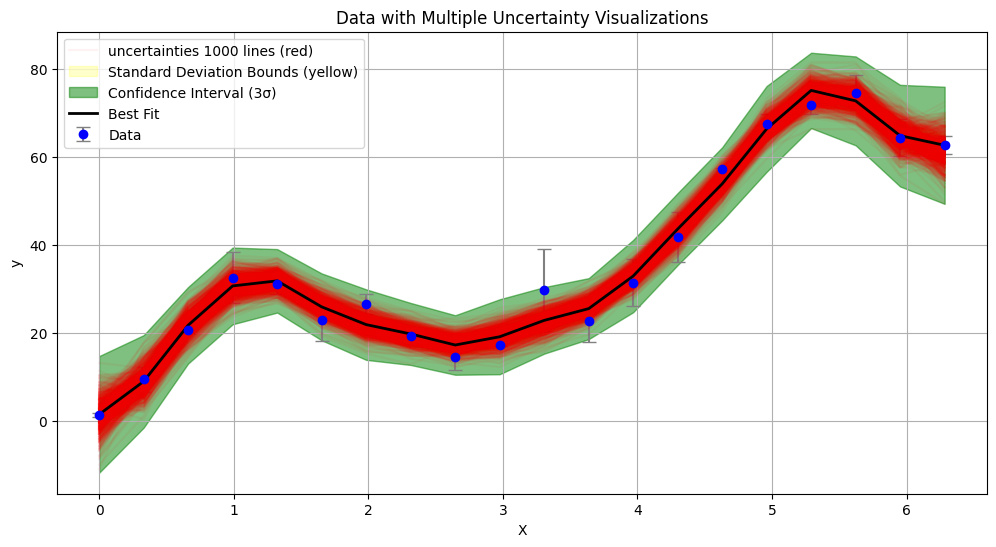

In [69]:
#comparing all the ways to display the uncertainty in one plot:
plt.figure(figsize=(12, 6))

# Plot the data with their error bars
plt.errorbar(X, y, yerr=yerror, fmt='o', color='blue', ecolor='gray', capsize=5, label='Data')

# Plot the "hand made way"
for i, params in enumerate(sampled_params):
    if i == 0:
        plt.plot(X, model_func(X, *params), color='red', alpha=0.05, label='uncertainties 1000 lines (red)')
    else:
        plt.plot(X, model_func(X, *params), color='red', alpha=0.05)
  # Use low alpha for transparency

# Plot standard "not best way"
plt.fill_between(X, lower_bound, upper_bound, color='yellow', alpha=0.2, label='Standard Deviation Bounds (yellow)')

# Plot the quick way (for three standard deviations)
plt.fill_between(X, y_fit - conf_intervals, y_fit + conf_intervals, color='green', alpha=0.5, label='Confidence Interval (3σ)')

# Plot 
plt.plot(X, y_fit, '-', color='black', label='Best Fit', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Data with Multiple Uncertainty Visualizations')
plt.legend()
plt.grid(True)
plt.show()

In [56]:
residuals = lambda params, x, y, y_error: (y - model_func(x, *params)) / y_error

minimizer = lmfit.Minimizer(residuals, params, fcn_args=(X, y, yerror))
result_minimize = minimizer.minimize()
print(result_minimize.fit_report())

AttributeError: 'MinimizerResult' object has no attribute 'params'